In [1]:
import sys
import itertools
sys.path.append('../')
import random
from core import LADTransferTreeBoost, LSTransferTreeBoost, MTransferTreeBoost
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb #baseline
from utils import *

In [2]:
train_size = 200 #set train size here!! Make sure not to overwrite a saved experiment!!!!

In [23]:
def gaussian_noise(n_samples, signal_y, snr=3.0, random_seed = None):
    """
    Generate Gaussian noise with variance scaled to achieve the desired SNR
    relative to the variance of signal_y.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    signal_var = np.var(signal_y)
    target_noise_var = signal_var / snr
    noise = np.random.normal(0, 1, size=n_samples)
    noise_std = np.std(noise)
    noise *= np.sqrt(target_noise_var) / noise_std
    return noise


def slash_noise(n_samples, signal_y, snr=3.0, random_seed = None):
    """
    Generate Slash-distributed noise (Z/U) scaled to achieve desired SNR.
    """
    if random_seed is not None:
        np.random.seed(random_seed)
    signal_var = np.var(signal_y)
    target_noise_var = signal_var / snr

    u = np.random.normal(0, 1, size=n_samples)
    v = np.random.uniform(0.001, 1, size=n_samples)
    #v = np.where(v < 1e-6, 1e-6, v)  # prevent divide-by-zero
    raw_noise = u / v

    # Scale to achieve target variance
    noise_std = np.std(raw_noise)
    scaled_noise = raw_noise * np.sqrt(target_noise_var) / noise_std
    return scaled_noise




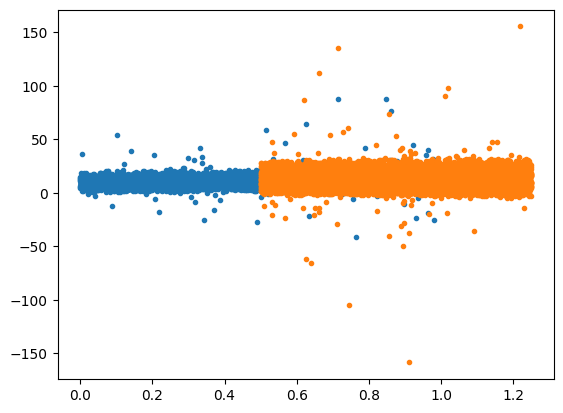

In [ ]:
def friedman1(n_samples, add_noise=False, noise_distribution='slash', n_features=5, random_seed=None):
    if random_seed is not None:
        np.random.seed(random_seed)

    x0 = np.random.uniform(0,1,size=n_samples)
    x1 = np.random.uniform(0,1,size=n_samples)
    x2 = np.random.uniform(0,1,size=n_samples)
    x3 = np.random.uniform(0,1,size=n_samples)
    x4 = np.random.uniform(0,1,size=n_samples)
    X = np.column_stack((x0, x1, x2, x3, x4)) 
    y = 10*np.sin(x0*x1) + 20*(x2 - 0.5)**2 + 10*x3 + 5*x4

    if add_noise:
        if noise_distribution == 'gaussian':
            if random_seed is not None:
                eps = gaussian_noise(n_samples, y, random_seed = random_seed)
            else:
                eps = gaussian_noise(n_samples, y)
            y += eps
        elif noise_distribution == 'slash':
            if random_seed is not None:
                eps = slash_noise(n_samples, y, random_seed = random_seed)
            else:
                eps = slash_noise(n_samples, y)
            
            y += eps
        else:
            raise Exception("No valid distribution, only gaussian or slash are accepted")

    if n_features > 5:
        noise_features = np.random.uniform(0, 1, size=(n_samples, n_features - 5))
        X = np.hstack((X, noise_features))

    return X, y


def friedman1_altered(n_samples, add_noise=False, noise_distribution='slash', n_features=5,
                      altering_level=0.1, constant_level=0.05,
                      pred_alter=0.1, pred_constant=10,
                      shift_seed=None, random_seed=None):

    if random_seed is not None:
        np.random.seed(random_seed)
    
    shift_rng = np.random.RandomState(shift_seed)

    scale_factors = 1 + altering_level * shift_rng.choice([-1, 1], size=5)
    shift_constants = constant_level * shift_rng.choice([-1, 1], size=5)

    x0 = np.random.uniform(0,1,size=n_samples) * scale_factors[0] + shift_constants[0]
    x1 = np.random.uniform(0,1,size=n_samples) * scale_factors[1] + shift_constants[1]
    x2 = np.random.uniform(0,1,size=n_samples) * scale_factors[2] + shift_constants[2]
    x3 = np.random.uniform(0,1,size=n_samples) * scale_factors[3] + shift_constants[3]
    x4 = np.random.uniform(0,1,size=n_samples) * scale_factors[4] + shift_constants[4]

    X = np.column_stack((x0, x1, x2, x3, x4))

    pred_scale = 1 + pred_alter * shift_rng.choice([-1, 1])
    pred_shift = pred_constant * shift_rng.choice([-1, 1])

    y = (10*np.sin(x0*x1) + 20*(x2 - 0.5)**2 + 10*x3 + 5*x4) * pred_scale + pred_shift

    if add_noise:
        if noise_distribution == 'gaussian':
            eps = gaussian_noise(n_samples, y)
            y += eps
        elif noise_distribution == 'slash':
            eps = slash_noise(n_samples, y)
            y += eps
        else:
            raise Exception("No valid distribution, only gaussian or slash are accepted")

    if n_features > 5:
        noise_features = np.random.uniform(0, 1, size=(n_samples, n_features - 5))
        X = np.hstack((X, noise_features))

    return X, y




X, y = friedman1(10000, add_noise = True, noise_distribution = 'slash', n_features=10, random_seed = 1)
X_altered, y_altered= friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'slash',
                                                   n_features=10, altering_level = 0.25, constant_level = 0.5, pred_alter=0.25, pred_constant=0.5, shift_seed=1, random_seed = 1) 

plt.plot(X[:,0], y, '.')
plt.plot(X_altered[:,0], y_altered, '.')
plt.show()

plt.plot(X[:,1], y, '.')
plt.plot(X_altered[:,1], y_altered, '.')
plt.show()

plt.plot(X[:,2], y, '.')
plt.plot(X_altered[:,2], y_altered, '.')
plt.show()

plt.plot(X[:,3], y, '.')
plt.plot(X_altered[:,3], y_altered, '.')
plt.show()

plt.plot(X[:,4], y, '.')
plt.plot(X_altered[:,4], y_altered, '.')
plt.show()


In [5]:
def train_xgboost(data_train, labels_train, boosting_rounds, params):

    dtrain = xgb.DMatrix(data_train, label=labels_train)

    # Train with evaluation set and early stopping
    evallist = [(dtrain, 'train')]

    bst = xgb.train(params, dtrain, num_boost_round=boosting_rounds, evals=evallist, verbose_eval=False)

    return bst

def test_xgboost(data_test, bst):
    
    dtest = xgb.DMatrix(data_test)
    preds = bst.predict(dtest)
    return preds

In [ ]:
#ablation study for transfertreeboost Gaussian errors, with gaussian source domain errors
ablation_transfer_normal_normal = pd.DataFrame(columns = ['seed', 'disturbance_level', 'rmse',
                                   'mae', 'source_tree_size', 'target_tree_size', 'v', 'alpha', 'epochs', 'method'])

alter_list = [0.05, 0.20]
constant_list = [0.1, 0.4]
seed_list = [1]
epoch_list = [100*i for i in range(1,7)]
v_list = [0.05]
source_tree_size_list = [2]
target_tree_size_list = [2]
alpha_list = [0.7]

# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    epoch_list,
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    alpha_list
))

# --- Step 3: Sample random combinations ---
random.seed(42)  # FIXED seed for reproducibility across methods
n_samples = 50   # or whatever budget you choose
#sampled_configs = random.sample(param_grid, n_samples)

for seed in seed_list:
    disturbance_level  = 0
    X_target_test, y_target_test = friedman1(10000, add_noise = False, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(train_size, add_noise = True, noise_distribution = 'gaussian', n_features=10, random_seed=seed) #add noise to train set
    for alter, constant in zip(alter_list, constant_list):
        disturbance_level += 1
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'gaussian',
                                                        n_features=10, altering_level = alter, 
                                                        constant_level = constant, pred_alter=alter, 
                                                        pred_constant=constant, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
        for config in param_grid:
            epochs, v, source_tree_size, target_tree_size, alpha = config


            #Test for all methods!!!!

            method = f'LSTransferTreeBoost (alpha = {0.5}, s,t = {2,1})'
            fiter = LSTransferTreeBoost(epochs=epochs, v=v, source_tree_size=2, 
                                        target_tree_size=1, alpha = 0.5)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                    mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')

            method = f'LSTransferTreeBoost (alpha = {0.1}, s,t = {2,1})'
            fiter = LSTransferTreeBoost(epochs=epochs, v=v, source_tree_size=2, 
                                        target_tree_size=1, alpha = 0.1)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                    mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')

            method = f'LSTransferTreeBoost (alpha = {0.9}, s,t = {2,1})'
            fiter = LSTransferTreeBoost(epochs=epochs, v=v, source_tree_size=2, 
                                        target_tree_size=1, alpha = 0.9)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                    mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')

            method = f'LSTransferTreeBoost (beta = {0.7}, s,t = {2,1})'
            fiter = LSTransferTreeBoost(epochs=epochs, v=v, source_tree_size=2, 
                                        target_tree_size=1, alpha = 0.7)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                    mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')






            #method = f'LADTransferTreeBoost'
            #fiter = LADTransferTreeBoost(epochs=epochs, v=v, decay_factor=tau, source_tree_size=source_tree_size, 
                                        #target_tree_size=target_tree_size, alpha_0 = 0.5)
            #fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            #rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            #mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

           # ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                    #mae, source_tree_size, target_tree_size, v, tau, epochs, method]
            #ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')

            #method = 'MTransferTreeBoost'
            #fiter = MTransferTreeBoost(epochs=epochs, v=v, decay_factor=tau, source_tree_size=source_tree_size, 
                                        #target_tree_size=target_tree_size, quantile = 0.9)
            #fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            #rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            #mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            #ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                    #mae, source_tree_size, target_tree_size, v, tau, epochs, method]
            #ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')

            #We also append baseline results!!
            method = 'Baseline (XGBoost)'
            params = {
                'objective': 'reg:squarederror',  # Regression with squared error
                'max_depth': target_tree_size,                   # Maximum depth of a tree
                'eta': v,                       # Learning rate
                'eval_metric': 'rmse',           # RMSE as evaluation metric
                }
                    
            bst = train_xgboost(X_target_train, y_target_train, boosting_rounds=epochs, params=params)
            preds = test_xgboost(X_target_test, bst)
            rmse = compute_rmse(preds, y_target_test)
            mae = compute_mae(preds, y_target_test)
            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                                mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            
            ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')
                            
        



KeyboardInterrupt: 

In [ ]:
#ablation study for transfertreeboost Gaussian errors, with gaussian source domain errors
ablation_transfer_slash_slash = pd.DataFrame(columns = ['seed', 'disturbance_level', 'rmse',
                                   'mae', 'source_tree_size', 'target_tree_size', 'v', 'alpha', 'epochs', 'method'])

alter_list = [0.05, 0.20, 0.35]
constant_list = [0.1, 0.4, 0.7]
seed_list = [1]
epoch_list = [100*i for i in range(1,7)]
v_list = [0.05]
source_tree_size_list = [2]
target_tree_size_list = [2]
alpha_list = [0.7]

# --- Step 2: Create full parameter grid ---
param_grid = list(itertools.product(
    epoch_list,
    v_list,
    source_tree_size_list,
    target_tree_size_list,
    alpha_list
))

# --- Step 3: Sample random combinations ---
random.seed(42)  # FIXED seed for reproducibility across methods
n_samples = 50   # or whatever budget you choose
#sampled_configs = random.sample(param_grid, n_samples)

for seed in seed_list:
    disturbance_level  = 0
    X_target_test, y_target_test = friedman1(10000, add_noise = False, noise_distribution = 'slash', n_features=10, random_seed=seed) #do NOT add noise to test set!!!!
    X_target_train, y_target_train = friedman1(train_size, add_noise = True, noise_distribution = 'slash', n_features=10, random_seed=seed) #add noise to train set
    for alter, constant in zip(alter_list, constant_list):
        disturbance_level += 1
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'slash',
                                                        n_features=10, altering_level = alter, 
                                                        constant_level = constant, pred_alter=alter, 
                                                        pred_constant=constant, shift_seed=seed, random_seed = seed) #also add noise to source (only train here)
        for config in param_grid:
            epochs, v, source_tree_size, target_tree_size, alpha = config


            #Test for all methods!!!!

            method = f'LADTransferTreeBoost (alpha = {0.5}, s,t = {2,2})'
            fiter = LADTransferTreeBoost(epochs=epochs, v=v, source_tree_size=2, 
                                        target_tree_size=2, alpha = 0.5)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            ablation_transfer_slash_slash.loc[len(ablation_transfer_slash_slash)] = [seed, disturbance_level, rmse,
                    mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            ablation_transfer_slash_slash.to_csv(f'ablation_transfer_slash_slash_{train_size}.csv')

            method = f'LADTransferTreeBoost (alpha = {0.5}, s,t = {2,1})'
            fiter = LADTransferTreeBoost(epochs=epochs, v=v, source_tree_size=2, 
                                        target_tree_size=1, alpha = 0.5)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            ablation_transfer_slash_slash.loc[len(ablation_transfer_slash_slash)] = [seed, disturbance_level, rmse,
                    mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            ablation_transfer_slash_slash.to_csv(f'ablation_transfer_slash_slash_{train_size}.csv')

            method = f'LADTransferTreeBoost (alpha = {0.5}, s,t = {1,2})'
            fiter = LADTransferTreeBoost(epochs=epochs, v=v, source_tree_size=1, 
                                        target_tree_size=2, alpha = 0.5)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            ablation_transfer_slash_slash.loc[len(ablation_transfer_slash_slash)] = [seed, disturbance_level, rmse,
                    mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            ablation_transfer_slash_slash.to_csv(f'ablation_transfer_slash_slash_{train_size}.csv')

            method = f'LADTransferTreeBoost (beta = {0.5}, s,t = {3,1})'
            fiter = LADTransferTreeBoost(epochs=epochs, v=v, source_tree_size=3, 
                                        target_tree_size=1, alpha = 0.5)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            ablation_transfer_slash_slash.loc[len(ablation_transfer_slash_slash)] = [seed, disturbance_level, rmse,
                    mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            ablation_transfer_slash_slash.to_csv(f'ablation_transfer_slash_slash_{train_size}.csv')






            #method = f'LADTransferTreeBoost'
            #fiter = LADTransferTreeBoost(epochs=epochs, v=v, decay_factor=tau, source_tree_size=source_tree_size, 
                                        #target_tree_size=target_tree_size, alpha_0 = 0.5)
            #fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            #rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            #mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

           # ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                    #mae, source_tree_size, target_tree_size, v, tau, epochs, method]
            #ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')

            #method = 'MTransferTreeBoost'
            #fiter = MTransferTreeBoost(epochs=epochs, v=v, decay_factor=tau, source_tree_size=source_tree_size, 
                                        #target_tree_size=target_tree_size, quantile = 0.9)
            #fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            #rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            #mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            #ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                    #mae, source_tree_size, target_tree_size, v, tau, epochs, method]
            #ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')

            #We also append baseline results!!
            method = 'Baseline (XGBoost)'
            params = {
                'objective': 'reg:squarederror',  # Regression with squared error
                'max_depth': target_tree_size,                   # Maximum depth of a tree
                'eta': v,                       # Learning rate
                'eval_metric': 'rmse',           # RMSE as evaluation metric
                }
                    
            bst = train_xgboost(X_target_train, y_target_train, boosting_rounds=epochs, params=params)
            preds = test_xgboost(X_target_test, bst)
            rmse = compute_rmse(preds, y_target_test)
            mae = compute_mae(preds, y_target_test)
            ablation_transfer_normal_normal.loc[len(ablation_transfer_normal_normal)] = [seed, disturbance_level, rmse,
                                mae, source_tree_size, target_tree_size, v, alpha, epochs, method]
            
            ablation_transfer_normal_normal.to_csv(f'ablation_transfer_normal_normal_{train_size}.csv')
                            
        



KeyboardInterrupt: 

In [ ]:
#ablation study for xgboost #might do! Implement with LAD loss
#For now, let us skip this, we will add as baseline in the future
ablation_xgboost = pd.DataFrame(columns = ['seed', 'disturbance_level', 'rmse',
                                   'mae', 'tree_size', 'v', 'epochs'])

alter_list = [0.05, 0.15, 0.25]
constant_list = [0.1, 0.3, 0.5]
seed_list = [1,2,3]
epoch_list = [100, 200,300,400,500,600]
v_list = [0.05, 0.1, 0.15, 0.2]
tree_size_list = [1,2,3,4,5]
for seed in seed_list:
    disturbance_level  = 0
    for alter, constant in zip(alter_list, constant_list):
        disturbance_level += 1
        X_target_test, y_target_test = friedman1(n_samples=10000, noise=0.2, n_features=10) 
        X_target_train, y_target_train = friedman1(n_samples=300, noise=0.0, n_features=10)
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, noise=0.2, 
                                                        n_features=10, altering_level = alter, 
                                                        constant_level = constant, pred_alter=alter, 
                                                        pred_constant=constant, shift_seed=seed) 
        
        for epochs in epoch_list:
            for v in v_list:
                for tree_size in tree_size_list:

        
        
                    params = {
                        'objective': 'reg:squarederror',  # Regression with squared error
                        'max_depth': tree_size,                   # Maximum depth of a tree
                        'eta': v,                       # Learning rate
                        'eval_metric': 'rmse',           # RMSE as evaluation metric
                    }
                    
                    bst = train_xgboost(X_target_train, y_target_train, boosting_rounds=epochs, params=params)
                    preds = test_xgboost(X_target_test, bst)
                    rmse = compute_rmse(preds, y_target_test)
                    mae = compute_mae(preds, y_target_test)
                    ablation_xgboost.loc[len(ablation_xgboost)] = [seed, disturbance_level, rmse,
                                            mae, tree_size, v, epochs]
                    ablation_xgboost.to_csv('ablation_xgboost.csv')

#here we run experiments with optimal parameters obtained from the previous experiments
#ablation study for transfertreeboost

optimal_params_simulations_transfer = pd.DataFrame(columns = ['seed', 'disturbance_level', 'rmse', 'mae'])
optimal_params_transfer = pd.read_csv('../optimal_params_transfer.csv') #read optimal params

alter_list = [0.05, 0.15, 0.25]
constant_list = [0.1, 0.3, 0.5]
seed_list = [10,11,12]

for seed in seed_list:
    disturbance_level  = 0
    for alter, constant in zip(alter_list, constant_list):
        disturbance_level += 1
        X_target_test, y_target_test = friedman1(10000, add_noise = False, noise_distribution = 'gaussian', n_features=10) #do NOT add noise to test set!!!!
        X_target_train, y_target_train = friedman1(300, add_noise = True, noise_distribution = 'gaussian', n_features=10) #add noise to train set
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'gaussian',
                                                        n_features=10, altering_level = alter, 
                                                        constant_level = constant, pred_alter=alter, 
                                                        pred_constant=constant, shift_seed=seed) #also add noise to source (only train here)
        for index, row in optimal_params_transfer[optimal_params_transfer['disturbance_level'] == disturbance_level].iterrows():
            source_tree_size, target_tree_size, v, tau, epochs = int(row['source_tree_size']), int(row['target_tree_size']), row['v'], row['tau'], int(row['epochs'])
            fiter = LSTransferTreeBoost(epochs=epochs, v=v, decay_factor=tau, source_tree_size=source_tree_size, 
                                        target_tree_size=target_tree_size)
            fiter.fit(X_target_train, y_target_train, X_source_train, y_source_train)
            rmse = fiter.evaluate(X_target_test, y_target_test, metric = 'rmse')
            mae = fiter.evaluate(X_target_test, y_target_test, metric = 'mae')

            optimal_params_simulations_transfer.loc[len(optimal_params_simulations_transfer)] = [seed, disturbance_level, rmse, mae]
            optimal_params_simulations_transfer.to_csv('optimal_params_simulations_transfer.csv')
        

#here we run experiments with optimal parameters obtained from the previous experiments
#ablation study for xgboost

optimal_params_simulations_xgboost = pd.DataFrame(columns = ['seed', 'disturbance_level', 'rmse', 'mae'])
optimal_params_xgboost = pd.read_csv('../optimal_params_xgboost.csv') #read optimal params

alter_list = [0.05, 0.15, 0.25]
constant_list = [0.1, 0.3, 0.5]
seed_list = [10,11,12]

for seed in seed_list:
    disturbance_level  = 0
    for alter, constant in zip(alter_list, constant_list):
        disturbance_level += 1
        X_target_test, y_target_test = friedman1(10000, add_noise = False, noise_distribution = 'gaussian', n_features=10) #do NOT add noise to test set!!!!
        X_target_train, y_target_train = friedman1(300, add_noise = True, noise_distribution = 'gaussian', n_features=10) #add noise to train set
        X_source_train, y_source_train = friedman1_altered(n_samples=10000, add_noise = True, noise_distribution = 'gaussian',
                                                        n_features=10, altering_level = alter, 
                                                        constant_level = constant, pred_alter=alter, 
                                                        pred_constant=constant, shift_seed=seed) #also add noise to source (only train here)
        for index, row in optimal_params_xgboost[optimal_params_xgboost['disturbance_level'] == disturbance_level].iterrows():
            tree_size, v, epochs = int(row['tree_size']), row['v'], int(row['epochs'])
            params = {
            'objective': 'reg:squarederror',  # Regression with squared error
            'max_depth': tree_size,                   # Maximum depth of a tree
            'eta': v,                       # Learning rate
            'eval_metric': 'rmse',           # RMSE as evaluation metric
        }
                    
            bst = train_xgboost(X_target_train, y_target_train, boosting_rounds=epochs, params=params)
            preds = test_xgboost(X_target_test, bst)
            rmse = compute_rmse(preds, y_target_test)
            mae = compute_mae(preds, y_target_test)
            optimal_params_simulations_xgboost.loc[len(optimal_params_simulations_xgboost)] = [seed, disturbance_level, rmse, mae]
            optimal_params_simulations_xgboost.to_csv('optimal_params_simulations_xgboost.csv')